# Fold-local SISSO/Boruta Y-randomization

This notebook runs and visualizes the response-permutation experiment requested during revision. The computational functions live in separate Python modules in this directory.

For the observed response and every shuffled response, the workflow creates five outer folds, fits the SISSO/Boruta feature generator using only each outer-training partition, reconstructs the selected expressions on the corresponding untouched outer-test partition, performs repeated inner-CV 1-SE LASSO selection with fold-local scaling, and produces one OOF prediction per observation.

## Methodological scope

SISSO/Boruta is rerun in every **outer-training fold**. It is not rerun again within each inner fold used to optimize the LASSO alpha. Consequently, the reported outer OOF performance is protected from feature-selection leakage into the held-out observations, while the alpha search is conditional on the representation selected from its complete outer-training partition. This distinction should be stated explicitly in the response to the reviewer.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from nested_lasso import LassoConfig
from sisso_fold_features import SISSOConfig
from run_sisso_y_randomization import (
    ExperimentConfig,
    inspect_progress,
    load_fold_debug,
    load_experiment_results,
    load_input_table,
    run_experiment,
)
from plot_sisso_y_randomization import (
    feature_selection_frequency,
    plot_best_randomized_parity,
    plot_null_distributions,
    plot_top_feature_frequencies,
    save_figure,
)

## Configuration

Start with one or two shuffles to verify the complete installation and estimate runtime. Use at least 200 shuffles for the first reportable null distribution; 1000 gives finer empirical p-value resolution. The run is checkpointed after every outer fold, and increasing `N_SHUFFLES` later resumes the existing calculation.

In [2]:
WORKFLOW_DIR = Path.cwd().resolve()
if not (WORKFLOW_DIR / "run_sisso_y_randomization.py").exists():
    raise RuntimeError(
        "Start Jupyter from the sisso_y_randomization directory before running."
    )

INPUT_FILE = WORKFLOW_DIR.parent / "training_set_base.csv"
LEGACY_SISSO_DIR = (
    WORKFLOW_DIR.parents[2] / "descriptor_generation" / "sisso"
)
OUTPUT_DIR = WORKFLOW_DIR / "results"

N_SHUFFLES = 2  # smoke test; increase to 200 or 1000 for reporting
RANDOM_STATE = 42

sisso_config = SISSOConfig(
    legacy_sisso_dir=LEGACY_SISSO_DIR,
    collinearity_cutoff=0.8,
    relative_filter_permutations=1000,
    boruta_percentile=75,
    boruta_max_iter=100,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=False,
    nonfinite_test_policy="raise",
)

lasso_config = LassoConfig(
    alphas=np.logspace(-4, -1, 100),
    n_bins=5,
    inner_splits=5,
    inner_repeats=4,
    random_state=RANDOM_STATE,
    max_iter=100_000,
)

config = ExperimentConfig(
    input_file=INPUT_FILE,
    output_dir=OUTPUT_DIR,
    legacy_sisso_dir=LEGACY_SISSO_DIR,
    n_shuffles=N_SHUFFLES,
    outer_splits=5,
    n_bins=5,
    random_state=RANDOM_STATE,
    resume=True,
    sisso=sisso_config,
    lasso=lasso_config,
)

print(f"Input: {INPUT_FILE}")
print(f"Legacy SISSO scripts: {LEGACY_SISSO_DIR}")
print(f"Results: {OUTPUT_DIR}")
print(f"Requested shuffles: {N_SHUFFLES}")

Input: /Users/luccapfitzer/Desktop/paper_imino/repository/catalyst-substrate-modeling/baseline_validation/training_set_base.csv
Legacy SISSO scripts: /Users/luccapfitzer/Desktop/paper_imino/repository/descriptor_generation/sisso
Results: /Users/luccapfitzer/Desktop/paper_imino/repository/catalyst-substrate-modeling/baseline_validation/sisso_y_randomization/results
Requested shuffles: 2


## Inspect the fixed linear input matrix

In [3]:
input_table, base_features = load_input_table(INPUT_FILE)
print(f"Rows: {len(input_table)}")
print(f"Base descriptors: {len(base_features)}")
display(input_table.head())

Rows: 146
Base descriptors: 28


,cat_substrate,ddG,x1,x2,x4,x5,x6,x7,x8,x9,...,x21,x22,x23,x24,x25,x26,x27,x28,x29,x30
0,KA2_A1,1.719047,80.570247,72.976572,0.32688,-0.398047,-0.798253,78.523006,54.199568,63.825052,...,-0.371293,65.001117,65.001117,61.135839,52.712682,-0.174130,0.014710,-0.312250,-0.112310,75.879021
1,KA2_A2,1.618875,80.570247,72.976572,0.32688,-0.398047,-0.798253,78.523006,54.199568,63.825052,...,-0.371064,65.052418,64.979701,61.170292,52.685893,-0.174002,0.014858,-0.311965,-0.111760,75.971806
2,KA2_A3,0.850944,80.570247,72.976572,0.32688,-0.398047,-0.798253,78.523006,54.199568,63.825052,...,-0.370103,65.483210,65.159416,61.079038,52.740635,-0.172925,0.015287,-0.305578,-0.112397,77.051048
3,KA2_A4,1.770180,80.570247,72.976572,0.32688,-0.398047,-0.798253,78.523006,54.199568,63.825052,...,-0.369797,65.021364,64.961077,61.243854,52.719670,-0.177385,0.012581,-0.319768,-0.097328,76.032035
4,KA2_A5,0.955859,80.570247,72.976572,0.32688,-0.398047,-0.798253,78.523006,54.199568,63.825052,...,-0.372869,68.966344,68.952063,74.154499,57.367569,-0.169511,0.018550,-0.109682,-0.143138,77.845423


## Run or resume the experiment

This is the expensive cell. The observed-response reference is evaluated first, followed by the requested permutations. Each completed outer fold is cached under `results/runs/`.

In [4]:
result = run_experiment(config)

  [observed] fitting SISSO/Boruta fold 1


/Users/luccapfitzer/anaconda3/envs/modeling/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.0031575645070855973, tolerance: 0.003089564642774685
  model = cd_fast.enet_coordinate_descent_gram(
/Users/luccapfitzer/anaconda3/envs/modeling/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.0031967177989224993, tolerance: 0.003089564642774685
  model = cd_fast.enet_coordinate_descent_gram(
/Users/luccapfitzer/anaconda3/envs/modeling/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.003092026333018527, tolerance: 0.003089564642774685
  model = cd_fast.enet_coordinat

    SISSO: 3080 bivariate -> 66 filtered; 628 Boruta candidates -> 64 selected
    LASSO: alpha_min=0.0030539, alpha_1se=0.023101, nonzero=12; train R2/MAE=0.784/0.216; test R2/MAE=0.739/0.212; 97.0 s
  [observed] fitting SISSO/Boruta fold 2


/Users/luccapfitzer/anaconda3/envs/modeling/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.150e-03, tolerance: 2.954e-03
  model = cd_fast.enet_coordinate_descent(
/Users/luccapfitzer/anaconda3/envs/modeling/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.099e-03, tolerance: 2.954e-03
  model = cd_fast.enet_coordinate_descent(
/Users/luccapfitzer/anaconda3/envs/modeling/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the sca

    SISSO: 3080 bivariate -> 66 filtered; 641 Boruta candidates -> 100 selected
    LASSO: alpha_min=0.0004037, alpha_1se=0.015199, nonzero=16; train R2/MAE=0.792/0.205; test R2/MAE=0.719/0.243; 134.4 s
  [observed] fitting SISSO/Boruta fold 3


...

    SISSO: 3080 bivariate -> 58 filtered; 582 Boruta candidates -> 7 selected
    LASSO: alpha_min=0.09326, alpha_1se=0.1, nonzero=2; train R2/MAE=0.065/0.437; test R2/MAE=-0.013/0.455; 56.7 s
  [permutation_0001] fitting SISSO/Boruta fold 5


/Users/luccapfitzer/anaconda3/envs/modeling/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.22083282044890318, tolerance: 0.003128709218423485
  model = cd_fast.enet_coordinate_descent_gram(


    SISSO: 3080 bivariate -> 71 filtered; 669 Boruta candidates -> 5 selected
    LASSO: alpha_min=0.057224, alpha_1se=0.1, nonzero=2; train R2/MAE=0.032/0.439; test R2/MAE=-0.017/0.479; 51.4 s
[2/2] permutation_0002
  [permutation_0002] fitting SISSO/Boruta fold 1
    SISSO: 3080 bivariate -> 73 filtered; 687 Boruta candidates -> 1 selected
    LASSO: alpha_min=0.081113, alpha_1se=0.1, nonzero=2; train R2/MAE=0.018/0.452; test R2/MAE=-0.003/0.443; 53.9 s
  [permutation_0002] fitting SISSO/Boruta fold 2


/Users/luccapfitzer/anaconda3/envs/modeling/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.003305098283810537, tolerance: 0.0031928121811221617
  model = cd_fast.enet_coordinate_descent_gram(
/Users/luccapfitzer/anaconda3/envs/modeling/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.00324723610155786, tolerance: 0.0031928121811221617
  model = cd_fast.enet_coordinate_descent_gram(
/Users/luccapfitzer/anaconda3/envs/modeling/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.012389511428160915, tolerance: 0.003043258181890914
  model = cd_fast.enet_coordinate

    SISSO: 3080 bivariate -> 75 filtered; 702 Boruta candidates -> 2 selected
    LASSO: alpha_min=0.086975, alpha_1se=0.1, nonzero=1; train R2/MAE=0.059/0.439; test R2/MAE=-0.051/0.452; 57.6 s
  [permutation_0002] fitting SISSO/Boruta fold 3
    SISSO: 3080 bivariate -> 86 filtered; 768 Boruta candidates -> 0 selected
    LASSO: alpha_min=0.1, alpha_1se=0.1, nonzero=0; train R2/MAE=0.000/0.458; test R2/MAE=-0.001/0.452; 54.2 s
  [permutation_0002] fitting SISSO/Boruta fold 4
    SISSO: 3080 bivariate -> 83 filtered; 746 Boruta candidates -> 3 selected
    LASSO: alpha_min=0.081113, alpha_1se=0.1, nonzero=1; train R2/MAE=0.024/0.448; test R2/MAE=0.009/0.447; 68.7 s
  [permutation_0002] fitting SISSO/Boruta fold 5
    SISSO: 3080 bivariate -> 72 filtered; 673 Boruta candidates -> 3 selected
    LASSO: alpha_min=0.1, alpha_1se=0.1, nonzero=1; train R2/MAE=0.006/0.451; test R2/MAE=-0.014/0.478; 55.8 s


## Load existing results without fitting

After restarting the kernel, run the configuration cells and this cell to regenerate tables and figures without rerunning SISSO.

In [ ]:
result = load_experiment_results(OUTPUT_DIR)

## Intermediate progress and debugging

This table can be inspected after an interruption or from a second notebook kernel while the command-line runner is active. Every completed fold has a structured JSON record, held-out predictions, the selected augmented-feature names, and the captured legacy SISSO log.

In [5]:
progress = inspect_progress(OUTPUT_DIR)
display(progress)

,response_id,completed_folds,response_complete,latest_fold,latest_fold_seconds,latest_selected_augmented,latest_alpha_1se,latest_log
0,observed,5,True,5,187.637253,93,0.005337,/Users/luccapfitzer/Desktop/paper_imino/reposi...
1,permutation_0001,5,True,5,51.364980,5,0.100000,/Users/luccapfitzer/Desktop/paper_imino/reposi...
2,permutation_0002,5,True,5,55.836869,3,0.100000,/Users/luccapfitzer/Desktop/paper_imino/reposi...


In [6]:
# Change these values to inspect a particular completed or active fold.
DEBUG_RESPONSE_ID = "observed"
DEBUG_OUTER_FOLD = 1

debug_record, debug_log = load_fold_debug(
    OUTPUT_DIR,
    DEBUG_RESPONSE_ID,
    DEBUG_OUTER_FOLD,
)
display(pd.Series(debug_record, name="value").to_frame())
print(debug_log[-5000:])  # final 5000 characters of the SISSO log

,value
response_id,observed
response_kind,observed
permutation,0
outer_fold,1
n_train,116
n_test,30
n_base_features,28
n_selected_augmented_features,64
n_total_features,92
selected_augmented_features,x1_div_x26;x11_div_x9;x19_div_x5;x21_mul_x30;x...


[Filtering] Starting filtering of augmented features from iteration 1...
[Filtering] Checking collinearity (cutoff: 0.8)...
[Filtering] Dropping 3014 features due to collinearity.
[Filtering] Retaining 66 features after collinearity filtering.
[Filtering] Starting permutation testing (relative)...
  Permutation testing 0/66
  Permutation testing 10/66
  Permutation testing 20/66
  Permutation testing 30/66
  Permutation testing 40/66
  Permutation testing 50/66
  Permutation testing 60/66
[Filtering] Features retained after filtering: 66



## Numerical summary

In [7]:
display(result.empirical_significance.style.format(precision=4))

summary_columns = [
    "response_id",
    "mean_in_fold_r2",
    "mean_in_fold_mae",
    "oof_r2",
    "oof_mae",
    "alpha_1se_median",
    "selected_augmented_median",
    "nonzero_lasso_median",
]
display(result.response_summary[summary_columns].style.format(precision=4))

,metric,observed,null_mean,null_std,p_value,n_permutations
0,oof_r2,0.7897,-0.0095,0.0009,0.3333,2
1,oof_mae,0.1944,0.4537,0.0009,0.3333,2
2,mean_in_fold_r2,0.8469,0.0318,0.0147,0.3333,2
3,mean_in_fold_mae,0.1729,0.4469,0.0042,0.3333,2


,response_id,mean_in_fold_r2,mean_in_fold_mae,oof_r2,oof_mae,alpha_1se_median,selected_augmented_median,nonzero_lasso_median
0,observed,0.8469,0.1729,0.7897,0.1944,0.0053,93.0000,18.0000
1,permutation_0001,0.0422,0.4440,-0.0089,0.4531,0.1000,5.0000,2.0000
2,permutation_0002,0.0215,0.4499,-0.0102,0.4544,0.1000,2.0000,1.0000


## OOF null distributions

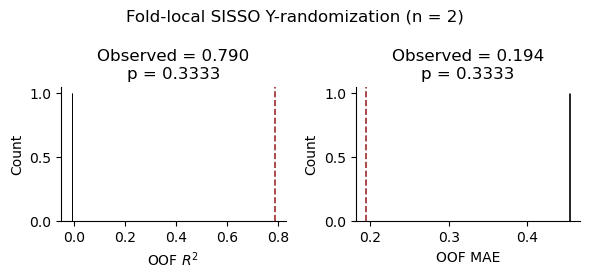

In [8]:
null_figure, null_axes = plot_null_distributions(
    result.response_summary,
    result.empirical_significance,
)
save_figure(null_figure, OUTPUT_DIR / "sisso_y_randomization_null_distributions")
plt.show()

## Best randomized-model parity plot

The displayed points are strictly outer-fold predictions from the permutation with the highest OOF R².

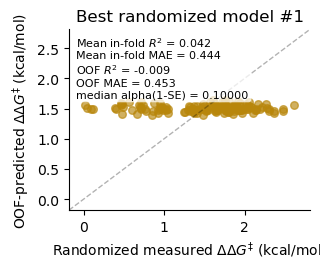

In [9]:
parity_figure, parity_axis = plot_best_randomized_parity(
    result.response_summary,
    result.predictions,
)
save_figure(parity_figure, OUTPUT_DIR / "best_randomized_model_parity")
plt.show()

## SISSO/Boruta selection stability for the observed response

,feature,selection_count,selection_frequency
0,cbrt_x11divx9,5,1.00
1,cbrt_x1divx26,5,1.00
2,cbrt_x21mulx30,5,1.00
3,cbrt_x27addx5,5,1.00
4,cbrt_x30,5,1.00
5,exp_x11divx9,5,1.00
6,exp_x21mulx30,5,1.00
7,exp_x27addx5,5,1.00
8,inv_x11divx9,5,1.00
9,inv_x11subx12,5,1.00


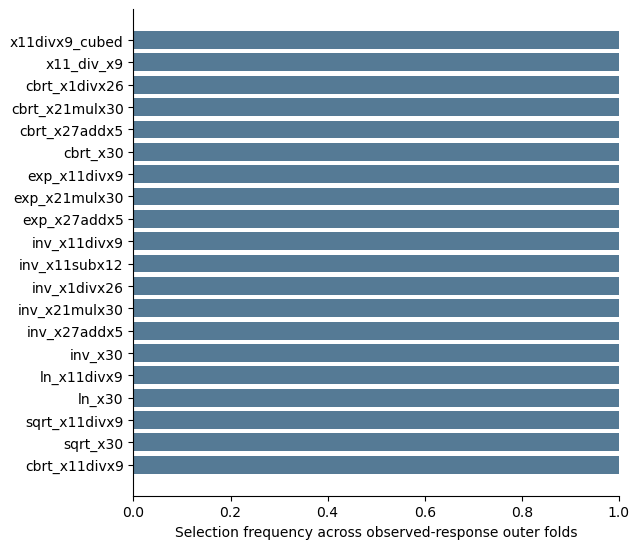

In [10]:
observed_feature_frequency = feature_selection_frequency(
    result.fold_metrics,
    response_kind="observed",
)
display(observed_feature_frequency.head(25).style.format({"selection_frequency": "{:.2f}"}))

if not observed_feature_frequency.empty:
    feature_figure, feature_axis = plot_top_feature_frequencies(
        result.fold_metrics,
        top_n=20,
    )
    save_figure(feature_figure, OUTPUT_DIR / "observed_feature_selection_frequency")
    plt.show()

## Fold-level audit table

In [11]:
audit_columns = [
    "response_id",
    "outer_fold",
    "n_train",
    "n_test",
    "n_selected_augmented_features",
    "alpha_min",
    "alpha_1se",
    "n_nonzero",
    "in_fold_r2",
    "in_fold_mae",
    "outer_test_r2",
    "outer_test_mae",
    "elapsed_seconds",
]
display(result.fold_metrics[audit_columns].style.format(precision=4))

,response_id,outer_fold,n_train,n_test,n_selected_augmented_features,alpha_min,alpha_1se,n_nonzero,in_fold_r2,in_fold_mae,outer_test_r2,outer_test_mae,elapsed_seconds
0,observed,1,116,30,64,0.0031,0.0231,12,0.7840,0.2161,0.7386,0.2121,96.9939
1,observed,2,117,29,100,0.0004,0.0152,16,0.7916,0.2050,0.7185,0.2432,134.3563
2,observed,3,117,29,85,0.0003,0.0006,30,0.9163,0.1274,0.8434,0.1323,169.5346
3,observed,4,117,29,100,0.0031,0.0046,22,0.8739,0.1529,0.8472,0.1865,124.9771
4,observed,5,117,29,93,0.0019,0.0053,18,0.8686,0.1632,0.7801,0.1975,187.6373
5,permutation_0001,1,116,30,13,0.0081,0.1000,2,0.0445,0.4516,0.0141,0.4159,72.4620
6,permutation_0001,2,117,29,2,0.1000,0.1000,2,0.0306,0.4473,-0.0119,0.4661,56.7909
7,permutation_0001,3,117,29,2,0.0870,0.1000,1,0.0388,0.4454,-0.0333,0.4513,51.7381
8,permutation_0001,4,117,29,7,0.0933,0.1000,2,0.0654,0.4367,-0.0133,0.4546,56.6507
9,permutation_0001,5,117,29,5,0.0572,0.1000,2,0.0317,0.4388,-0.0168,0.4790,51.3650
